# Random Forest — pIC50 Prediction
**Fixed:** data leakage | 60/20/20 split | correct Q² | external validation uses pre-trained model

## 1. Main Pipeline (load → split → preprocess → train → evaluate)

Split — Train: 3417 (60%)  Test: 1140 (20%)  Val: 1140 (20%)
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters: {'n_estimators': 250, 'max_depth': 15}

Train R²: 0.949  |  RMSE: 0.317  |  MAE: 0.221  |  Q² (8-fold CV): 0.785
Test  R²: 0.817  |  RMSE: 0.599  |  MAE: 0.440
Training Time: 1251.67 sec


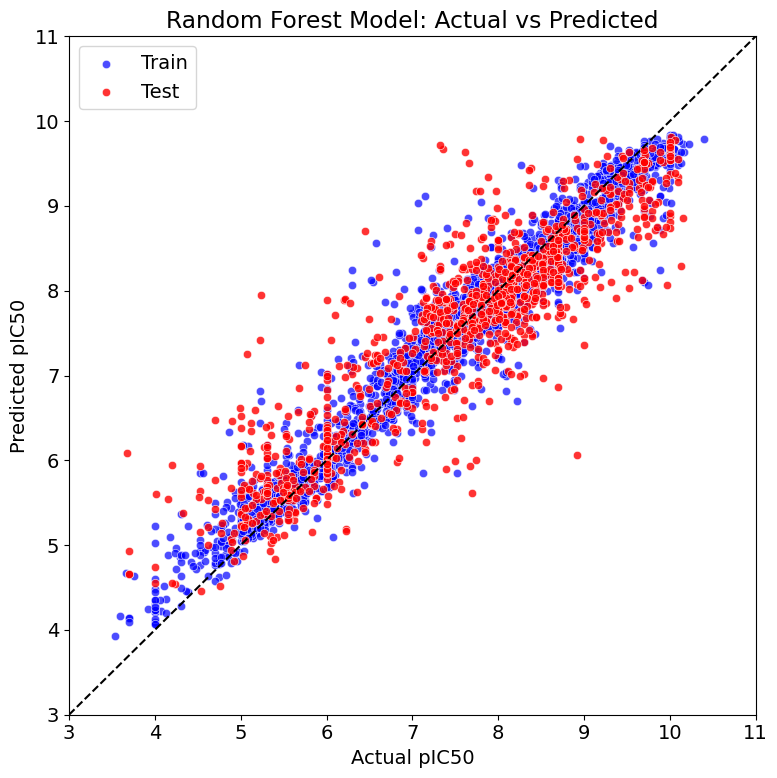

In [12]:
import pandas as pd
import numpy as np
import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ─────────────────────────────────────────
# 1. Load data
# ─────────────────────────────────────────
df = pd.read_csv('MDM2_main_input.csv', low_memory=False)
ids     = df['Smiles'] if 'Smiles' in df.columns else pd.Series([f'Mol_{i}' for i in range(len(df))])
target  = df['pIC50']
features = df.drop(columns=['Smiles', 'pIC50'], errors='ignore')
features = features.apply(pd.to_numeric, errors='coerce')
features = features.dropna(axis=1)

# ─────────────────────────────────────────
# 2. Split FIRST — 60% train | 20% test | 20% val
#    FIX: all preprocessing fitted on X_train only
# ─────────────────────────────────────────
X_temp, X_val, y_temp, y_val, id_temp, id_val = train_test_split(
    features, target, ids, test_size=0.20, random_state=42)
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X_temp, y_temp, id_temp, test_size=0.25, random_state=42)   # 0.25 x 0.80 = 0.20

print(f"Split — Train: {len(X_train)} ({len(X_train)/len(df):.0%})  "
      f"Test: {len(X_test)} ({len(X_test)/len(df):.0%})  "
      f"Val: {len(X_val)} ({len(X_val)/len(df):.0%})")

# ─────────────────────────────────────────
# 3. Variance threshold — fit on X_train only
# ─────────────────────────────────────────
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train)
kept_cols = X_train.columns[selector.get_support()]
X_train = pd.DataFrame(selector.transform(X_train), columns=kept_cols)
X_test  = pd.DataFrame(selector.transform(X_test),  columns=kept_cols)
X_val   = pd.DataFrame(selector.transform(X_val),   columns=kept_cols)

# ─────────────────────────────────────────
# 4. Correlation filter — computed on X_train only
# ─────────────────────────────────────────
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
X_train = X_train.drop(columns=to_drop)
X_test  = X_test.drop(columns=to_drop)
X_val   = X_val.drop(columns=to_drop)

# ─────────────────────────────────────────
# 5. Feature importance selection — fit on X_train only
# ─────────────────────────────────────────
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train, y_train)
importances = pd.Series(rf_selector.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(50).index
X_train = X_train[top_features]
X_test  = X_test[top_features]
X_val   = X_val[top_features]

with open('used_feature_names.txt', 'w') as f:
    for col in top_features:
        f.write(f"{col}\n")
pd.DataFrame({'feature': top_features}).to_csv('used_features.csv', index=False)

# ─────────────────────────────────────────
# 6. Scaling — fit on X_train only
# ─────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=top_features)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=top_features)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val),       columns=top_features)
joblib.dump(scaler, 'scaler.pkl')

# ─────────────────────────────────────────
# 7. Save split CSVs (unscaled, with Smiles)
# ─────────────────────────────────────────
def save_split(smiles_s, X, y, path):
    pd.concat([smiles_s.reset_index(drop=True),
               X.reset_index(drop=True),
               y.reset_index(drop=True)], axis=1).to_csv(path, index=False)

train_smiles = df.loc[id_train.index, 'Smiles'].reset_index(drop=True)
test_smiles  = df.loc[id_test.index,  'Smiles'].reset_index(drop=True)
val_smiles   = df.loc[id_val.index,   'Smiles'].reset_index(drop=True)

save_split(train_smiles, X_train, y_train, 'train_set.csv')
save_split(test_smiles,  X_test,  y_test,  'test_set.csv')
save_split(val_smiles,   X_val,   y_val,   'validation_set.csv')

# ─────────────────────────────────────────
# 8. Hyperparameter tuning
# ─────────────────────────────────────────
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth':    [None, 10, 15, 20, 25],
}
randomized_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10, cv=5, n_jobs=-1, verbose=2, random_state=42
)
start_time = time.time()
randomized_search.fit(X_train_scaled, y_train)
best_model = randomized_search.best_estimator_
print(f"Best parameters: {randomized_search.best_params_}")

# ─────────────────────────────────────────
# 9. Predictions
# ─────────────────────────────────────────
y_train_pred = best_model.predict(X_train_scaled)
y_test_pred  = best_model.predict(X_test_scaled)

# ─────────────────────────────────────────
# 10. Q² — cross-validated R² on TRAINING set only (corrected)
#     R² on test/val already reflects held-out performance
# ─────────────────────────────────────────
kf = KFold(n_splits=8, shuffle=True, random_state=42)
q2_train_preds = cross_val_predict(
    RandomForestRegressor(
        n_estimators=randomized_search.best_params_['n_estimators'],
        max_depth=randomized_search.best_params_['max_depth'],
        random_state=42, n_jobs=-1),
    X_train_scaled, y_train, cv=kf)
q2_train = r2_score(y_train, q2_train_preds)

# ─────────────────────────────────────────
# 11. Metrics
# ─────────────────────────────────────────
result = {
    'train_r2':       r2_score(y_train, y_train_pred),
    'rmse_train':     np.sqrt(mean_squared_error(y_train, y_train_pred)),  # ADD
    'mae_train':      mean_absolute_error(y_train, y_train_pred),          # ADD
    'q2_train_cv':    q2_train,
    'test_r2':        r2_score(y_test,  y_test_pred),
    'rmse_test':      np.sqrt(mean_squared_error(y_test, y_test_pred)),
    'mae_test':       mean_absolute_error(y_test,  y_test_pred),
    'train_time_sec': round(time.time() - start_time, 2)
}
print(f"\nTrain R²: {result['train_r2']:.3f}  |  RMSE: {result['rmse_train']:.3f}  |  MAE: {result['mae_train']:.3f}  |  Q² (8-fold CV): {result['q2_train_cv']:.3f}")
print(f"Test  R²: {result['test_r2']:.3f}  |  RMSE: {result['rmse_test']:.3f}  |  MAE: {result['mae_test']:.3f}")
print(f"Training Time: {result['train_time_sec']} sec")

pd.DataFrame([result]).to_csv('model_performance.csv', index=False)
joblib.dump(best_model, 'final_rf_model.joblib')   # single file, single name

# ─────────────────────────────────────────
# 12. Actual vs Predicted plot
# ─────────────────────────────────────────
plt.figure(figsize=(8, 8))
plt.rcParams.update({'font.size': 14})
sns.scatterplot(x=y_train, y=y_train_pred, label='Train', color='blue',   alpha=0.7)
sns.scatterplot(x=y_test,  y=y_test_pred,  label='Test',  color='red', alpha=0.8)
plt.plot([3, 11], [3, 11], '--k')
plt.xlim(3, 11); plt.ylim(3, 11)
plt.xlabel('Actual pIC50'); plt.ylabel('Predicted pIC50')
plt.title('Random Forest Model: Actual vs Predicted')
plt.legend(); plt.tight_layout()
plt.savefig('actual_vs_predicted_best_model.png', dpi=300)
plt.show()

# ─────────────────────────────────────────
# 13. Save combined predictions
# ─────────────────────────────────────────
pd.concat([
    pd.DataFrame({'Smiles': train_smiles.values, 'Set': 'train',
                  'Actual_pIC50': y_train.values, 'Predicted_pIC50': y_train_pred}),
    pd.DataFrame({'Smiles': test_smiles.values,  'Set': 'test',
                  'Actual_pIC50': y_test.values,  'Predicted_pIC50': y_test_pred}),
], ignore_index=True).to_csv('actual_vs_predicted_with_sets.csv', index=False)


## 2. Y-Randomization

Real model   — R²: 0.8167  RMSE: 0.5992
Randomized   — R² mean: -0.0720  std: 0.0365


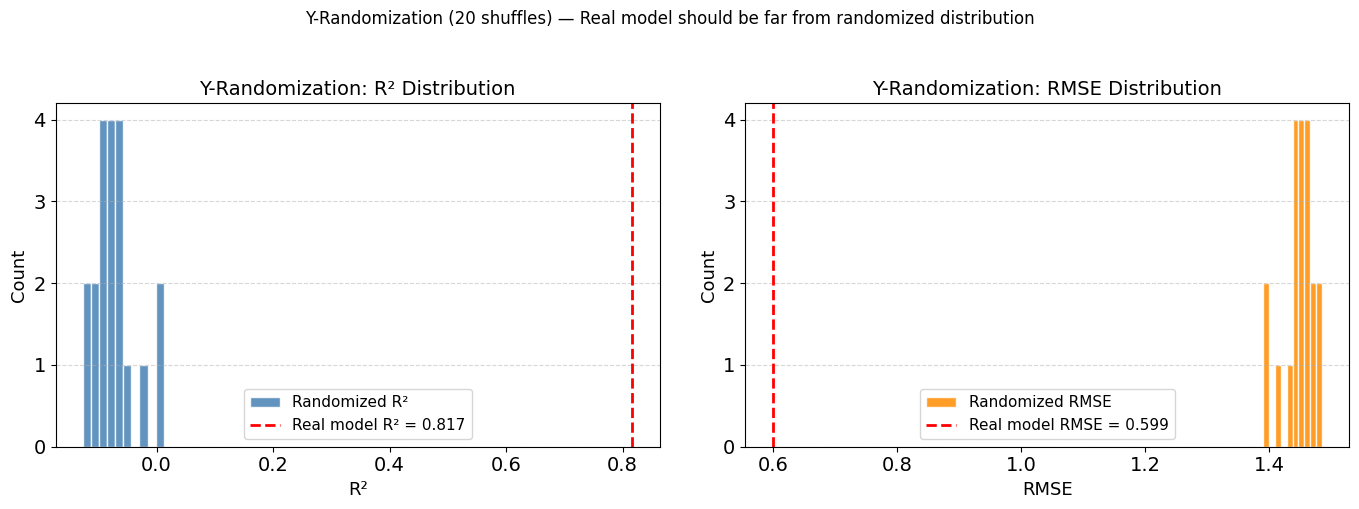

In [14]:
from sklearn.utils import shuffle
from sklearn.ensemble import RandomForestRegressor # ADDED: Import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error # ADDED: Ensure metrics are imported
import numpy as np # ADDED: Ensure numpy is imported
import pandas as pd # ADDED: Ensure pandas is imported
import joblib # ADDED: Ensure joblib is imported

# ─────────────────────────────────────────
# Y-Randomization — 20 iterations
# ─────────────────────────────────────────
n_iter = 20
r2_rand_list   = []
rmse_rand_list = []

# These lines should be executed once outside the loop
perf_df    = pd.read_csv('model_performance.csv')
best_model = joblib.load('final_rf_model.joblib')
# FIX: Corrected the syntax for best_params (removed '...')
# Assumes 'n_estimators' and 'max_depth' are the relevant parameters from the best_model
best_params = {
    'n_estimators': best_model.n_estimators,
    'max_depth': best_model.max_depth
}

# 'result' is a global variable defined in the previous cell
real_r2   = result['test_r2']
real_rmse = result['rmse_test']

for i in range(n_iter):
    y_shuffled = shuffle(y_train, random_state=i)
    # Removed: `train_df = pd.read_csv('train_set.csv')` was redundant and not used inside the loop

    # ADDED: Initialize rf_rand here, inside the loop, using the best parameters
    rf_rand = RandomForestRegressor(random_state=i, n_jobs=-1, **best_params)

    rf_rand.fit(X_train_scaled, y_shuffled)
    y_pred_rand = rf_rand.predict(X_test_scaled)
    r2_rand_list.append(r2_score(y_test, y_pred_rand))
    rmse_rand_list.append(np.sqrt(mean_squared_error(y_test, y_pred_rand)))

print(f"Real model   — R²: {real_r2:.4f}  RMSE: {real_rmse:.4f}")
print(f"Randomized   — R² mean: {np.mean(r2_rand_list):.4f}  std: {np.std(r2_rand_list):.4f}")

# Save results
rand_df = pd.DataFrame({
    'iteration':       range(1, n_iter + 1),
    'R2_randomized':   r2_rand_list,
    'RMSE_randomized': rmse_rand_list
})
rand_df['R2_real']   = real_r2
rand_df['RMSE_real'] = real_rmse
rand_df.to_csv('y_randomization_result.csv', index=False)

# ─────────────────────────────────────────
# Plot — R² distribution vs real model
# ─────────────────────────────────────────
import matplotlib.pyplot as plt # ADDED: Ensure matplotlib is imported
import seaborn as sns # ADDED: Ensure seaborn is imported

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: R² distribution
axes[0].hist(r2_rand_list, bins=10, color='steelblue', edgecolor='white', alpha=0.85, label='Randomized R²')
axes[0].axvline(real_r2, color='red', linewidth=2, linestyle='--', label=f'Real model R² = {real_r2:.3f}')
axes[0].set_xlabel('R²', fontsize=13)
axes[0].set_ylabel('Count', fontsize=13)
axes[0].set_title('Y-Randomization: R² Distribution', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Right: RMSE distribution
axes[1].hist(rmse_rand_list, bins=10, color='darkorange', edgecolor='white', alpha=0.85, label='Randomized RMSE')
axes[1].axvline(real_rmse, color='red', linewidth=2, linestyle='--', label=f'Real model RMSE = {real_rmse:.3f}')
axes[1].set_xlabel('RMSE', fontsize=13)
axes[1].set_ylabel('Count', fontsize=13)
axes[1].set_title('Y-Randomization: RMSE Distribution', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle(f'Y-Randomization ({n_iter} shuffles) — Real model should be far from randomized distribution',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('y_randomization_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. External Validation
> Evaluates the **pre-trained** model. No retraining or hyperparameter tuning here.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


External Validation — R²: 0.806  RMSE: 0.613  MAE: 0.443


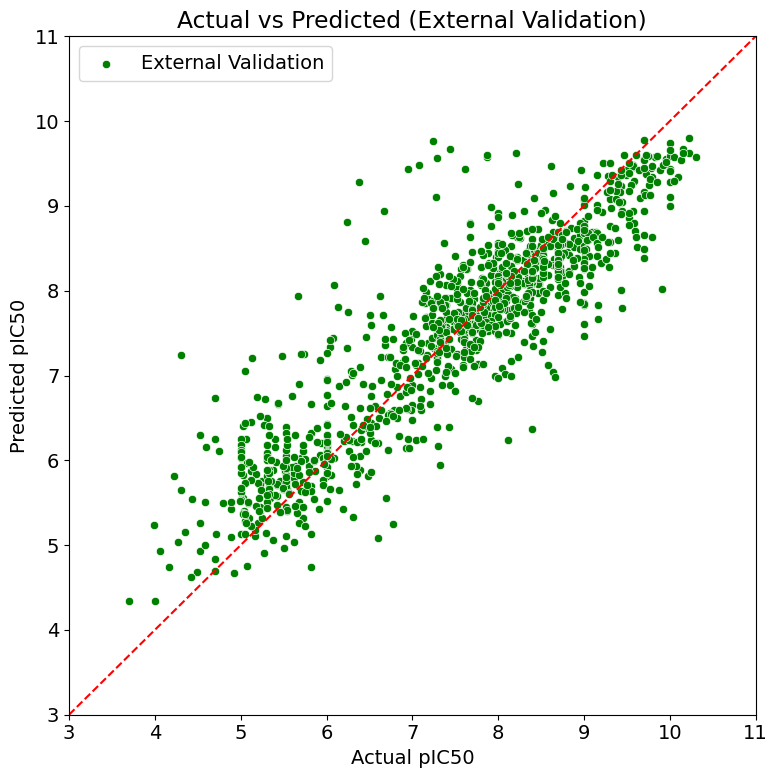

In [15]:
# ─────────────────────────────────────────
# External validation — NO retraining or tuning on this data
# ─────────────────────────────────────────
external_df = pd.read_csv('validation_set.csv', low_memory=False)
external_target   = external_df['pIC50']
external_features = external_df.drop(columns=['Smiles', 'pIC50'], errors='ignore')
external_features = external_features.apply(pd.to_numeric, errors='coerce').dropna(axis=1)

with open('used_feature_names.txt', 'r') as f:
    training_features = [line.strip() for line in f]

# Guard: verify all features present
missing = [feat for feat in training_features if feat not in external_features.columns]
if missing:
    raise ValueError(f"External data missing {len(missing)} training features: {missing[:5]}")

external_features = external_features[training_features]

# Scale using training scaler — do NOT refit
scaler_ext = joblib.load('scaler.pkl')
ext_scaled = scaler_ext.transform(external_features)

# Load trained model — do NOT retrain
best_model_ext = joblib.load('final_rf_model.joblib')

start_time = time.time()
ext_predictions = best_model_ext.predict(ext_scaled)
eval_time = round(time.time() - start_time, 2)

ext_r2   = r2_score(external_target, ext_predictions)
ext_rmse = np.sqrt(mean_squared_error(external_target, ext_predictions))
ext_mae  = mean_absolute_error(external_target, ext_predictions)

print(f"External Validation — R²: {ext_r2:.3f}  RMSE: {ext_rmse:.3f}  MAE: {ext_mae:.3f}")

pd.DataFrame([{
    'external_r2': ext_r2, 'external_rmse': ext_rmse,
    'external_mae': ext_mae, 'evaluation_time_sec': eval_time
}]).to_csv('external_validation_results.csv', index=False)

ext_out = external_df.copy()
ext_out['Predicted_pIC50'] = ext_predictions
ext_out.to_csv('predicted_activity_external.csv', index=False)

plt.figure(figsize=(8, 8))
sns.scatterplot(x=external_target, y=ext_predictions, color='green', label='External Validation')
plt.plot([3, 11], [3, 11], '--r')
plt.xlim(3, 11); plt.ylim(3, 11)
plt.xlabel('Actual pIC50'); plt.ylabel('Predicted pIC50')
plt.title('Actual vs Predicted (External Validation)')
plt.legend(); plt.tight_layout()
plt.savefig('external_validation_actual_vs_predicted.png', dpi=300)
plt.show()


## 4. Feature Importance & Correlation Heatmap

Top 10 Features:
   Feature  Importance
      GGI8    0.202373
SpMax4_Bhv    0.063133
   nHBint6    0.039825
  BCUTw-1h    0.038650
SpMax2_Bhm    0.037797
SpMax3_Bhm    0.034502
  minsssCH    0.026339
    SHssNH    0.025778
    minaaN    0.024352
     SdssC    0.021566


/tmp/ipykernel_5911/3519120191.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')


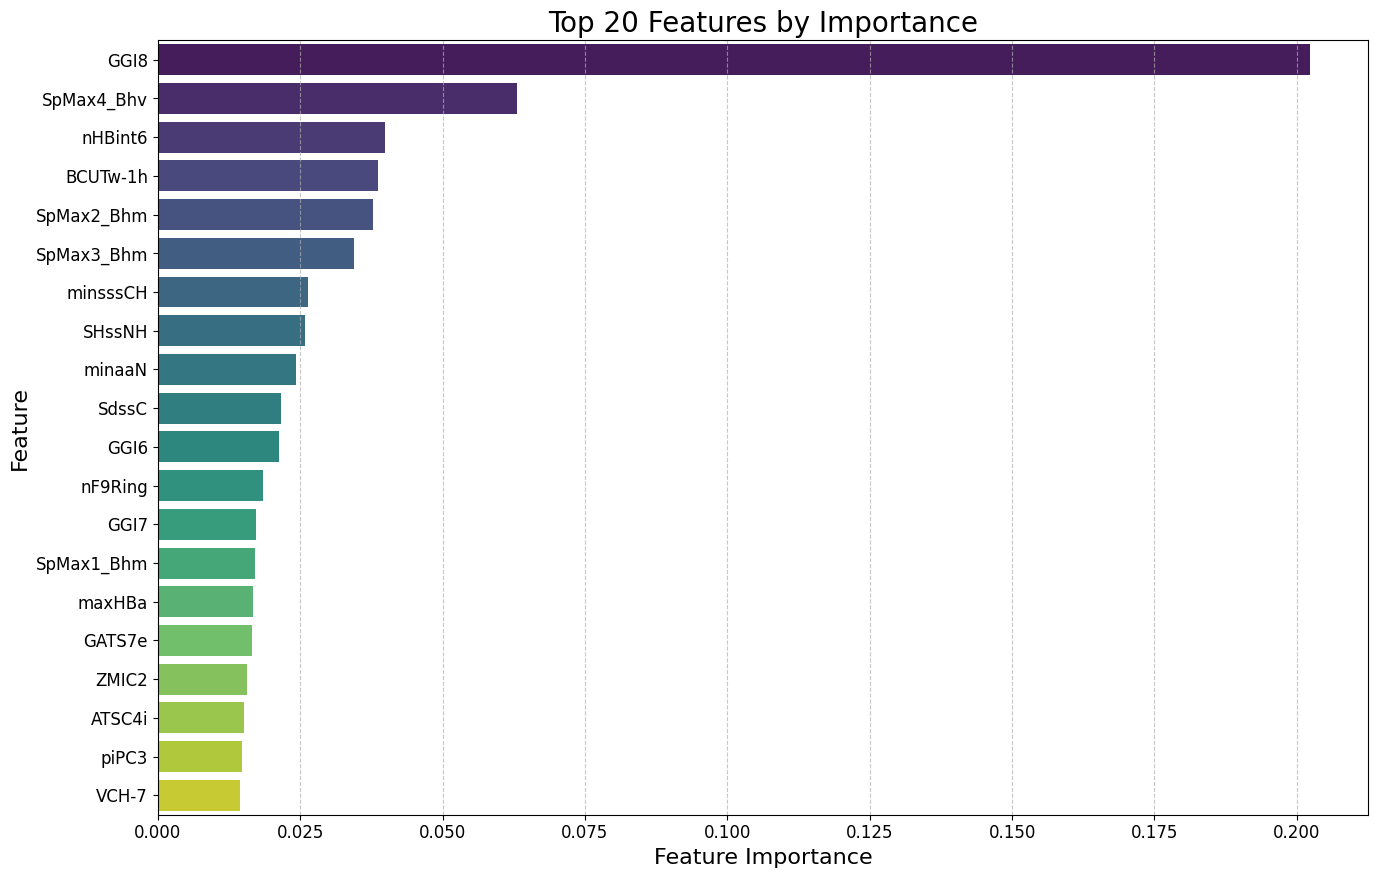

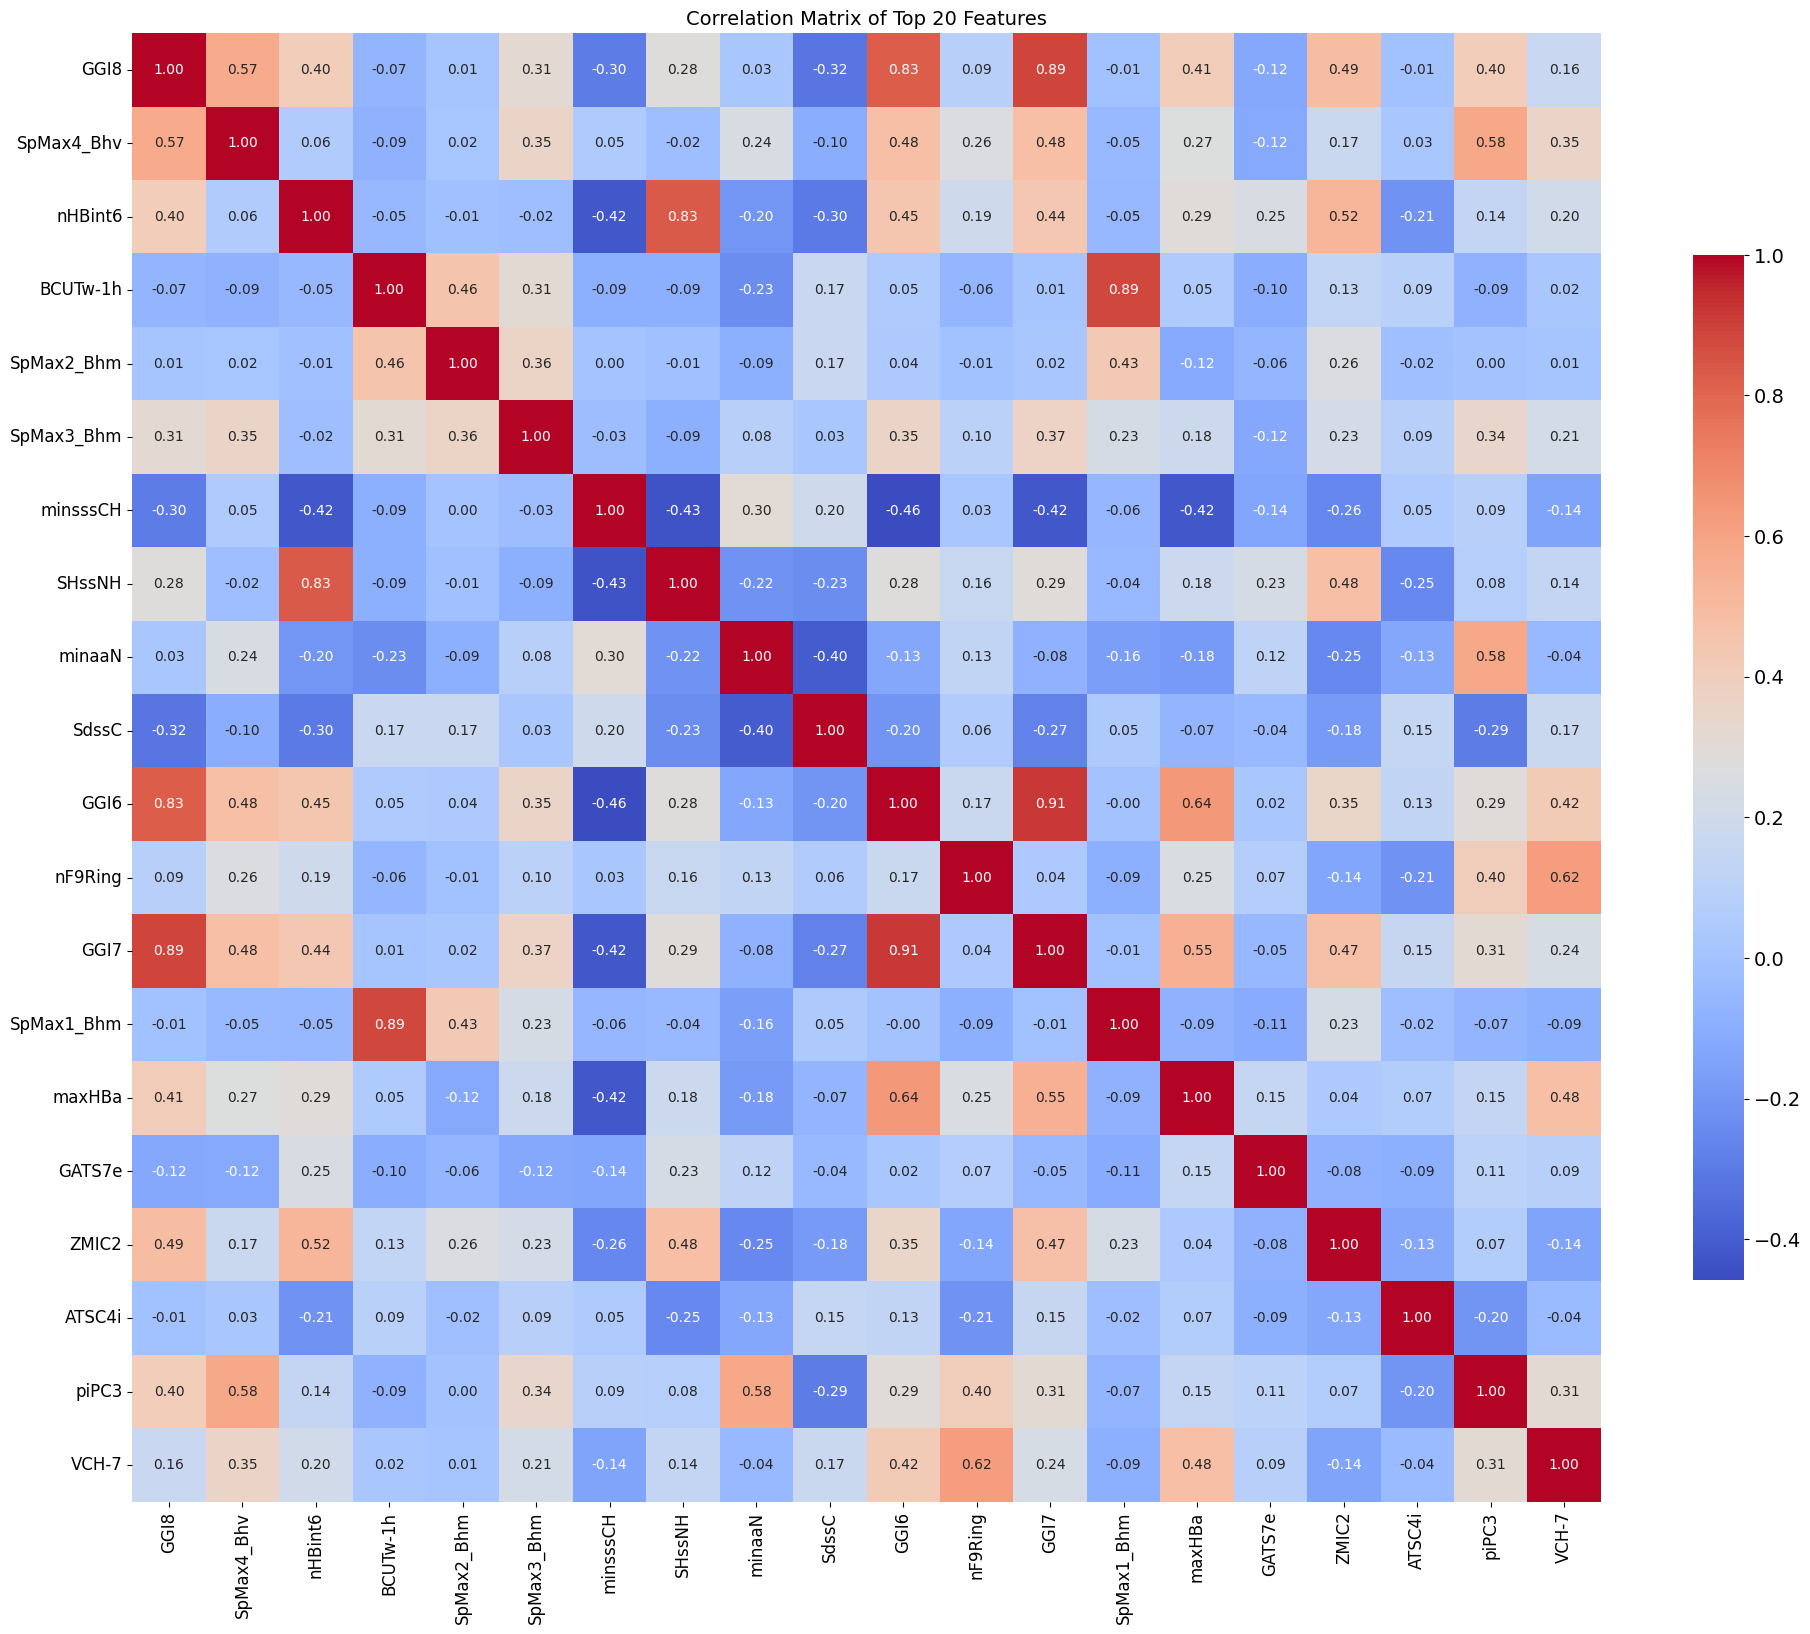

In [16]:
final_model = joblib.load('final_rf_model.joblib')

with open('used_feature_names.txt', 'r') as f:
    used_features = [line.strip() for line in f]

# Rebuild features from original CSV — drop Smiles (not 'Name')
df_interp = pd.read_csv('MDM2_main_input.csv', low_memory=False)
feat_interp = df_interp.drop(columns=['Smiles', 'pIC50'], errors='ignore')
feat_interp = feat_interp.apply(pd.to_numeric, errors='coerce').dropna(axis=1)

missing_feats = [f for f in used_features if f not in feat_interp.columns]
if missing_feats:
    raise ValueError(f"Missing features: {missing_feats[:5]}")

feat_interp = feat_interp[used_features]

importance_df = pd.DataFrame({
    'Feature': used_features,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Features:")
print(importance_df.head(10).to_string(index=False))

plt.figure(figsize=(14, 9))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title('Top 20 Features by Importance', fontsize=20)
plt.xlabel('Feature Importance', fontsize=16); plt.ylabel('Feature', fontsize=16)
plt.xticks(fontsize=12); plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('feature_importance_plot.png', dpi=600)
plt.show()
importance_df.to_csv('feature_importance.csv', index=False)

# Correlation heatmap — top 20 features sorted by importance
top20 = importance_df['Feature'].head(20).tolist()
plt.figure(figsize=(20, 18))
sns.heatmap(feat_interp[top20].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            square=True, cbar_kws={'shrink': 0.6}, annot_kws={'size': 10})
plt.xticks(rotation=90, fontsize=12); plt.yticks(rotation=0, fontsize=12)
plt.title('Correlation Matrix of Top 20 Features', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix_top20.png', dpi=600)
plt.show()


## 5. Applicability Domain (Euclidean Distance-Based)

AD threshold: 16.183
Test samples inside AD: 1119 / 1140 (98.2%)


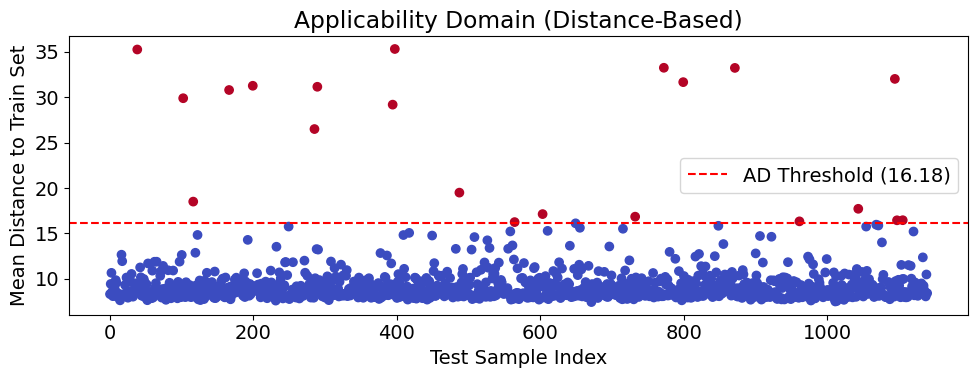

In [17]:
from sklearn.metrics.pairwise import euclidean_distances

# Note: requires X_train_scaled and X_test_scaled from Cell 1 in the same session
distances       = euclidean_distances(X_test_scaled, X_train_scaled)
mean_distances  = distances.mean(axis=1)

train_dists          = euclidean_distances(X_train_scaled, X_train_scaled)
mean_train_dists     = train_dists.mean(axis=1)
ad_threshold         = mean_train_dists.mean() + 3 * mean_train_dists.std()
ad_flag              = mean_distances <= ad_threshold

print(f"AD threshold: {ad_threshold:.3f}")
print(f"Test samples inside AD: {ad_flag.sum()} / {len(ad_flag)} ({ad_flag.mean():.1%})")

pd.DataFrame({
    'Smiles':          id_test.values,
    'Actual_pIC50':    y_test.values,
    'Predicted_pIC50': y_test_pred,
    'AD_Inside':       ad_flag,
    'Mean_Distance':   mean_distances
}).to_csv('test_set_with_ad_flag.csv', index=False)

plt.figure(figsize=(10, 4))
plt.scatter(range(len(mean_distances)), mean_distances,
            c=ad_flag.astype(int), cmap='coolwarm_r')
plt.axhline(y=ad_threshold, color='r', linestyle='--',
            label=f'AD Threshold ({ad_threshold:.2f})')
plt.xlabel('Test Sample Index'); plt.ylabel('Mean Distance to Train Set')
plt.title('Applicability Domain (Distance-Based)')
plt.legend(); plt.tight_layout()
plt.savefig('applicability_domain_plot.png', dpi=300)
plt.show()


In [18]:
# ─────────────────────────────────────────
# Download all output files to your computer
# ─────────────────────────────────────────
from google.colab import files

output_files = [
    # Data splits
    'train_set.csv',
    'test_set.csv',
    'validation_set.csv',
    # Model + scaler
    'final_rf_model.joblib',
    'scaler.pkl',
    # Feature info
    'used_features.csv',
    'used_feature_names.txt',
    # Metrics
    'model_performance.csv',
    'external_validation_results.csv',
    'y_randomization_result.csv',
    # Predictions
    'actual_vs_predicted_combined.csv',
    'predicted_activity_external.csv',
    'test_set_with_ad_flag.csv',
    'feature_importance.csv',
    # Plots
    'actual_vs_predicted_best_model.png',
    'external_validation_actual_vs_predicted.png',
    'y_randomization_plot.png',
    'feature_importance_plot.png',
    'correlation_matrix_top20.png',
    'applicability_domain_plot.png',
]

import os
for fname in output_files:
    if os.path.exists(fname):
        files.download(fname)
        print(f"Downloaded: {fname}")
    else:
        print(f"Not found (skipped): {fname}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: train_set.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: correlation_matrix_top20.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: applicability_domain_plot.png
